In [ ]:
IRkernel::installspec(user = FALSE)
options(repr.plot.width = 15, repr.plot.height = 15, repr.plot.res = 100)
plot(1:10) # For some weird reason, I cant plot dimplots at my preferred size if I dont first do this...
options(repr.matrix.max.cols = 100)
library(Seurat)
library(tidyverse)
library(qs)
library(edgeR)
library(gtools) # Mixedsort
set.seed(12345)

sun1 <- readRDS("/projects/perslab/people/jmg776/ad_hoc/martin_glp1r-sun1/glp1r-sun1_martin.RDS")
jenny_neurons <- qread("/projects/perslab/people/jmg776/ad_hoc/martin_glp1r-sun1/Raw_filtered_labeled_arc_dvc_major_class.qs") 
dvc_neurons <- readRDS("/projects/perslab/people/jmg776/projects/DVC/output/Seurat_objs/integrated/neurons_Seurat_obj_labels.rds")

# Main

In [6]:
# Region
sun1 <- subset(sun1, l1_neur == "Neurons")
sun1 <- subset(sun1, Glp1r > 0)

sun1 <- NormalizeData(sun1)
sun1 <- FindVariableFeatures(sun1)
sun1 <- ScaleData(sun1)
sun1 <- RunPCA(sun1)

sun1 <- FindNeighbors(sun1, dims = 1:15)
sun1 <- FindClusters(sun1)
sun1 <- RunUMAP(sun1, dims = 1:15)

region_anchors <- FindTransferAnchors(reference = jenny_neurons, query = sun1, dims = 1:30, reference.reduction = "pca") # Tried both 30 and 50 dims
region_predictions <- TransferData(anchorset = region_anchors, refdata = jenny_neurons$brainR, dims = 1:30, )
sun1$predicted.id.region <- region_predictions$predicted.id
sun1$predicted.score.region <- region_predictions$prediction.score.max

Centering and scaling data matrix

PC_ 1 
Positive:  Gm26871, Baiap3, Maml3, Dab1, Gria1, Gabrg3, Atp1a1, Dcc, Ccdc148, Efcab1 
	   Rgs9, Asic2, Zfhx3, Ddc, Parm1, Kcnc2, Nnat, Kcnd3, 1700042O10Rik, Ammecr1 
	   Dpyd, Tmcc3, Nell1, Ralyl, Dlgap2, March1, Kcnk2, Prkd1, Rnf220, Sema5a 
Negative:  Rgs6, Slc17a7, Lama1, Cabp1, Bcan, Kcna1, Ano3, Col27a1, Esrrg, Zfp385b 
	   Irx2, Cpne9, Spp1, Caln1, Foxn3, Sv2b, Me3, Scn1b, Mkx, Sh3bgrl2 
	   Coro6, Gm49906, Rbfox3, Sgcg, Msra, Rab37, Slc24a2, Ldlrap1, Sh3pxd2a, Kif26b 
PC_ 2 
Positive:  Cacna2d1, Rnf220, Chd7, Slit3, Slc17a7, Ddc, Tmtc2, Lama1, Chst8, Col27a1 
	   1700042O10Rik, Gch1, Nrn1, Etv1, Fam107b, Rftn1, Bdnf, Tcf4, Casr, Irx2 
	   Hs3st2, Gm49906, Slc6a2, Tanc1, Pirt, Ldlrap1, Pde4d, Xylt1, Parm1, Abtb2 
Negative:  Sv2c, Fat3, Kctd16, Cdh18, Grin2a, Asic2, Robo1, Khdrbs2, Prkg1, Epha5 
	   Nkain3, Prr16, Hs6st2, 6330411D24Rik, 8030451O07Rik, Gulp1, Ldb2, Adgrl2, Slc32a1, Nkain2 
	   Pax2, Rph3a, Lamp5, Chrm3, Col25a1, Cdh8, Etl4,

Modularity Optimizer version 1.3.0 by Ludo Waltman and Nees Jan van Eck

Number of nodes: 8141
Number of edges: 262502

Running Louvain algorithm...
Maximum modularity in 10 random starts: 0.9147
Number of communities: 28
Elapsed time: 0 seconds


Warning message:
“The default method for RunUMAP has changed from calling Python UMAP via reticulate to the R-native UWOT using the cosine metric
To use Python UMAP via reticulate, set umap.method to 'umap-learn' and metric to 'correlation'
This message will be shown once per session”
11:10:44 UMAP embedding parameters a = 0.9922 b = 1.112

11:10:44 Read 8141 rows and found 15 numeric columns

11:10:44 Using Annoy for neighbor search, n_neighbors = 30

11:10:44 Building Annoy index with metric = cosine, n_trees = 50

0%   10   20   30   40   50   60   70   80   90   100%

[----|----|----|----|----|----|----|----|----|----|

*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
|

11:10:45 Writing NN index file to temp file /scratch/tmp//RtmpuKkJx5/file1e20c567e6ca55

11:10:45 Searching Annoy index using 1 thread, search_k = 3000

11:10:47 Annoy recall = 100%

11:10:48 Commencing smooth kNN distance calibration using 1 thread
 with target n_

In [7]:
# DVC
sun1_dvc <- subset(sun1, predicted.id.region == "DVC")

sun1_dvc <- NormalizeData(sun1_dvc)
sun1_dvc <- FindVariableFeatures(sun1_dvc)
sun1_dvc <- ScaleData(sun1_dvc)
sun1_dvc <- RunPCA(sun1_dvc)
sun1_dvc <- FindNeighbors(sun1_dvc, dims = 1:15)
sun1_dvc <- FindClusters(sun1_dvc)
sun1_dvc <- RunUMAP(sun1_dvc, dims = 1:15)


dvc_neurons <- subset(dvc_neurons, dataset == "mouse.2023")

dvc_anchors_subset <- FindTransferAnchors(reference = dvc_neurons, query = sun1_dvc, dims = 1:30, reference.reduction = "pca", normalization.method = "SCT")
dvc_predictions_subset <- TransferData(anchorset = dvc_anchors_subset, refdata = dvc_neurons$cell.type, dims = 1:30, ) # Tried both 30 and 50 dims
sun1_dvc$predicted.id.dvc <- dvc_predictions_subset$predicted.id
sun1_dvc$predicted.score.dvc <- dvc_predictions_subset$prediction.score.max
sun1_dvc$predicted.id.dvc[sun1_dvc$predicted.score.dvc < 0.8] <- NA

Centering and scaling data matrix

PC_ 1 
Positive:  Hap1, Dcc, Camk2a, Rnf220, Maml3, Atp1a1, Kcnc2, Gabrg3, Mgat4c, Tshz2 
	   Zfhx3, Ddc, Asic2, Baiap3, Dab1, 1700042O10Rik, March1, Zfhx4, Rarb, Nell1 
	   Parm1, Ptprt, Gm26871, Luzp2, Gch1, Kcnk2, Etv1, Arhgef28, Prkd1, Phox2b 
Negative:  Zfp385b, Slc17a7, Lama1, Rgs6, Col27a1, Esrrg, Grm8, Ano3, Sv2b, Irx2 
	   Foxn3, Slc35f3, Gm49906, Cpne9, Rasgef1b, Bcan, Spp1, Cabp1, Msra, Me3 
	   Sgcg, Kcna1, Hcrtr2, Sh3bgrl2, Zfp536, Caln1, Col4a4, Ldlrap1, Gls, Nfib 
PC_ 2 
Positive:  Fat3, Sv2c, Kctd16, Lrrc7, Grin2a, Khdrbs2, Ldb2, Prr16, Cdh18, Nkain3 
	   Epha5, Robo1, Prkg1, Zfp804b, Etl4, Adgrl2, 6330411D24Rik, Gulp1, Asic2, 8030451O07Rik 
	   Slc32a1, Lamp5, Dgkb, Chrm3, Pax2, Gabrb1, Col25a1, Unc5d, Rph3a, Arhgap18 
Negative:  Cacna2d1, Rnf220, Tmtc2, Slit3, Ddc, Chst8, 1700042O10Rik, Chd7, Etv1, Rftn1 
	   Gch1, Bdnf, Nrn1, Pde4d, Ntng1, Parm1, Myo1b, Ptprn, Casr, Pirt 
	   Slc17a7, Slc6a2, Lama1, Tcf4, Fam107b, Xylt1, Lpcat2, Pho

Modularity Optimizer version 1.3.0 by Ludo Waltman and Nees Jan van Eck

Number of nodes: 5867
Number of edges: 185631

Running Louvain algorithm...
Maximum modularity in 10 random starts: 0.9098
Number of communities: 26
Elapsed time: 0 seconds


11:12:33 UMAP embedding parameters a = 0.9922 b = 1.112

11:12:33 Read 5867 rows and found 15 numeric columns

11:12:33 Using Annoy for neighbor search, n_neighbors = 30

11:12:33 Building Annoy index with metric = cosine, n_trees = 50

0%   10   20   30   40   50   60   70   80   90   100%

[----|----|----|----|----|----|----|----|----|----|

*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
|

11:12:34 Writing NN index file to temp file /scratch/tmp//RtmpuKkJx5/file1e20c531884f38

11:12:34 Searching Annoy index using 1 thread, search_k = 3000

11:12:35 Annoy recall = 100%

11:12:36 Commencing smooth kNN distance calibration using 1 thread
 with target n_neighbors = 30

11:12:37 Initializing from normalized Laplacian + noise (using RSpectra)

11:12:37 Commencing optimization for 500 epochs, with 238712 positive edges

11:12:42 Optimization finished

Normalizing query using reference SCT model

Projecting cell embeddings

Finding neighb

In [8]:
# Transfer DVC-only labels and define AP cells
meta_sun1 <- sun1@meta.data
meta_sun1_dvc <- sun1_dvc@meta.data
meta_sun1$predicted.id.dvc.only <- meta_sun1_dvc$predicted.id.dvc[
  match(rownames(meta_sun1), rownames(meta_sun1_dvc))]
sun1@meta.data <- meta_sun1

AP_cells <- c("GABA_0_0", "GABA_0_2", "Glu_2_1", "Glu_5_1", "Glu_5_2", "Glu_6_1")
sun1$is_AP <- ifelse(sun1$predicted.id.dvc.only %in% AP_cells, "AP", "Other")
Idents(sun1) <- sun1$is_AP

sun1_dvc$is_AP <- ifelse(sun1_dvc$predicted.id.dvc %in% AP_cells, "AP", "Other")
Idents(sun1_dvc) <- sun1_dvc$is_AP

In [9]:
# DEG
run_pseudobulk <- function(seurat_obj, sample_col, aggregate_by, 
                           lib_size = 5e4, 
                           min_gene_count = 5, 
                           min.total_gene_count = 20) {
    # 1. Create 'group' to aggregate by (here it's AP or Other)
    if (length(aggregate_by) > 1) {
        seurat_obj$group <- apply(
            seurat_obj@meta.data[, aggregate_by], 1, paste, collapse = "_"
        )
    } else if (length(aggregate_by) == 1) {
        seurat_obj$group <- seurat_obj@meta.data[, aggregate_by]
    }

    # 2. Convert single-cell to pseudobulk 
    DefaultAssay(seurat_obj) <- "RNA"
    pseudo <- Seurat2PB(seurat_obj, 
                        sample  = sample_col, 
                        cluster = "group")

    # 3. Filter pseudobulk matrix
    keep_samples <- pseudo$samples$lib.size > lib_size  
    keep_genes   <- filterByExpr(pseudo, 
                                 group           = pseudo$samples$cluster, 
                                 min.count       = min_gene_count, 
                                 min.total.count = min.total_gene_count)
    pseudo <- pseudo[keep_genes, keep_samples, keep=FALSE]

    # 4. Append additional metadata
    meta <- seurat_obj[[]] %>%
        distinct(!!sym(sample_col), .keep_all = TRUE) 
    meta <- meta[match(pseudo$samples$sample, meta[[sample_col]]), ]
    pseudo$samples <- bind_cols(meta, pseudo$samples)

    # 5. Normalize library sizes
    pseudo <- normLibSizes(pseudo)

    return(pseudo)
}

sun1_pseudo <- run_pseudobulk(
    seurat_obj = sun1, 
    sample_col = "hash.mcl.ID", 
    aggregate_by = "is_AP"
)

sun1_pseudo$samples$cluster <- factor(sun1_pseudo$samples$cluster)
sun1_pseudo$samples$cluster <- relevel(sun1_pseudo$samples$cluster, ref = "Other")
sun1_pseudo$samples$sample <- factor(sun1_pseudo$samples$sample)
design_matrix <- model.matrix(~ sample + cluster, data = sun1_pseudo$samples)

sun1_pseudo <- estimateDisp(sun1_pseudo, design_matrix, robust = TRUE)

fit <- glmQLFit(sun1_pseudo, design_matrix, robust = TRUE)
qlf <- glmQLFTest(fit, coef = "clusterAP")
top_table <- topTags(qlf, n = Inf)

top_genes <- top_table[top_table$table$FDR < 0.05,]%>%
    as.data.frame() %>% 
    arrange(desc(logFC)) %>%
    slice_head(n=10)

pcts <- FindMarkers(sun1, ident.1 = "AP", ident.2 = "Other")[rownames(top_genes),]

top_genes <- top_genes %>% 
    select(c("logFC", "FDR")) %>%
    mutate(pct.1 = pcts$pct.1, pct.2 = pcts$pct.2) %>%
    mutate(logFDR = -log10(FDR))

plot_genes <- top_genes %>%
  rownames_to_column("gene") %>%
  pivot_longer(cols = c("pct.1", "pct.2", "logFC", "logFDR"), names_to = "variable", values_to = "value") %>%
  mutate(facet_group = factor(case_when(
    variable %in% c("pct.1", "pct.2") ~ "pct",
    TRUE ~ variable
  ), levels = c("pct", "logFC", "logFDR"))) %>%
  group_by(gene) %>%
  mutate(pct1_val = value[variable == "pct.1"]) %>%
  ungroup() %>%
  mutate(gene = fct_reorder(gene, pct1_val, .desc = FALSE)) %>%
  mutate(variable = factor(variable, levels = c("pct.2", "pct.1", "logFC", "logFDR"))) %>%
  select(-pct1_val)

New names:
• `group` -> `group...39`
• `group` -> `group...40`


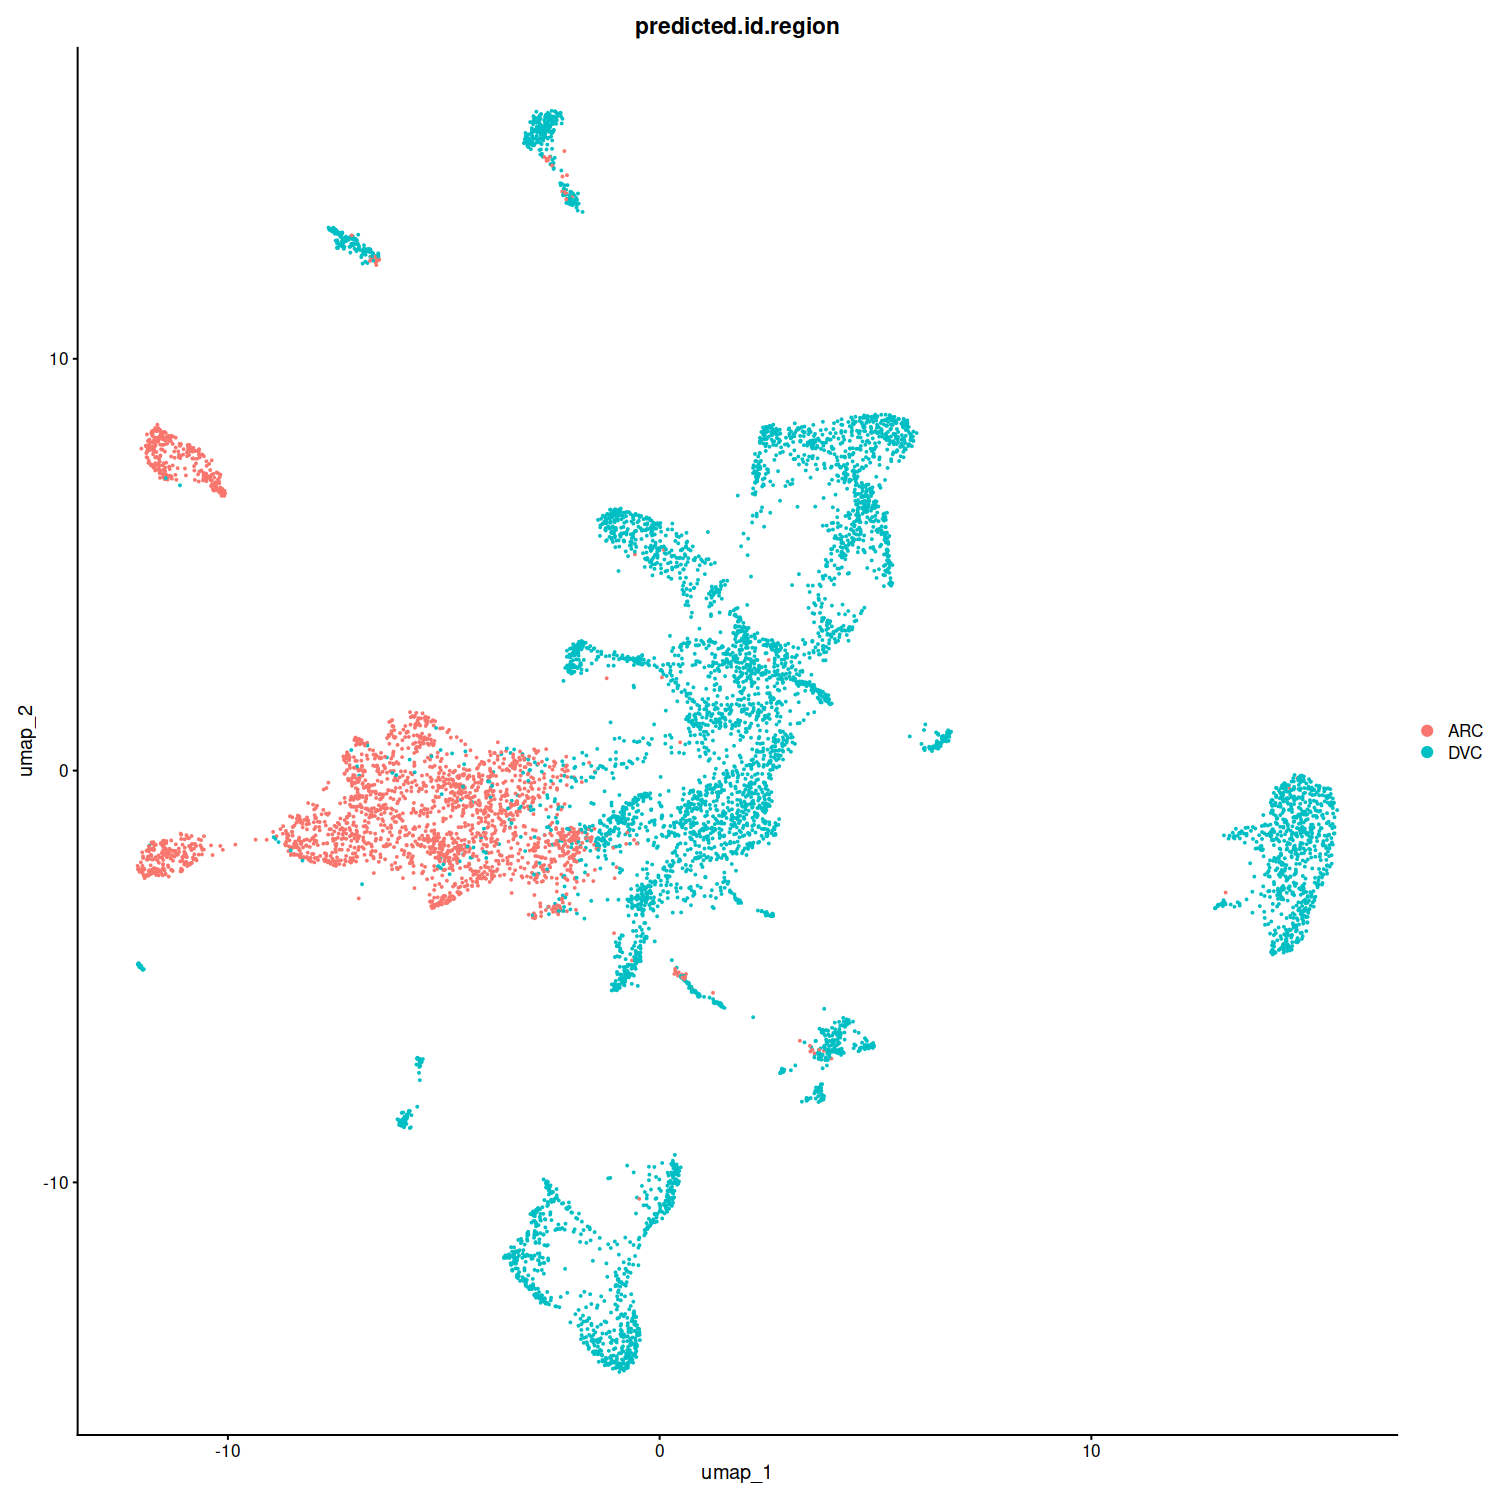

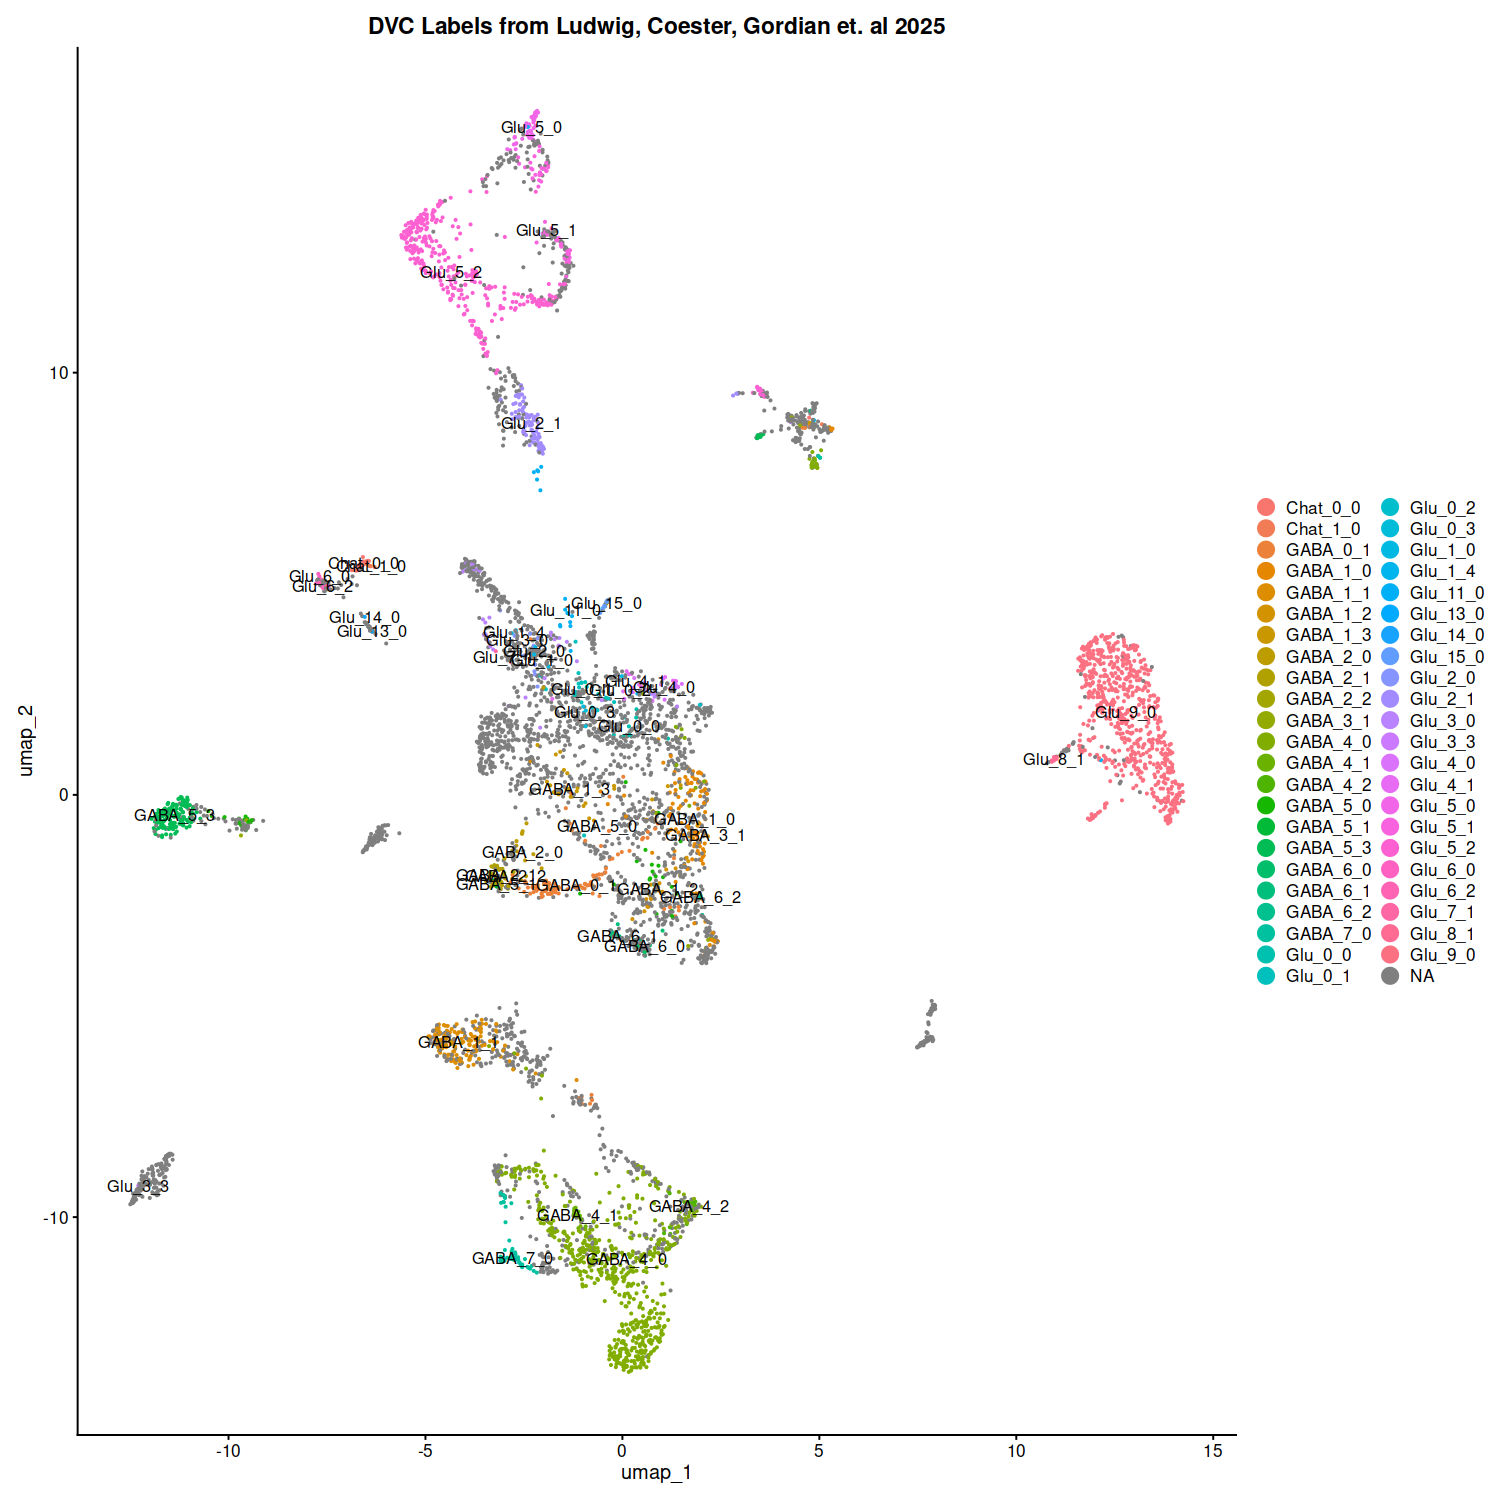

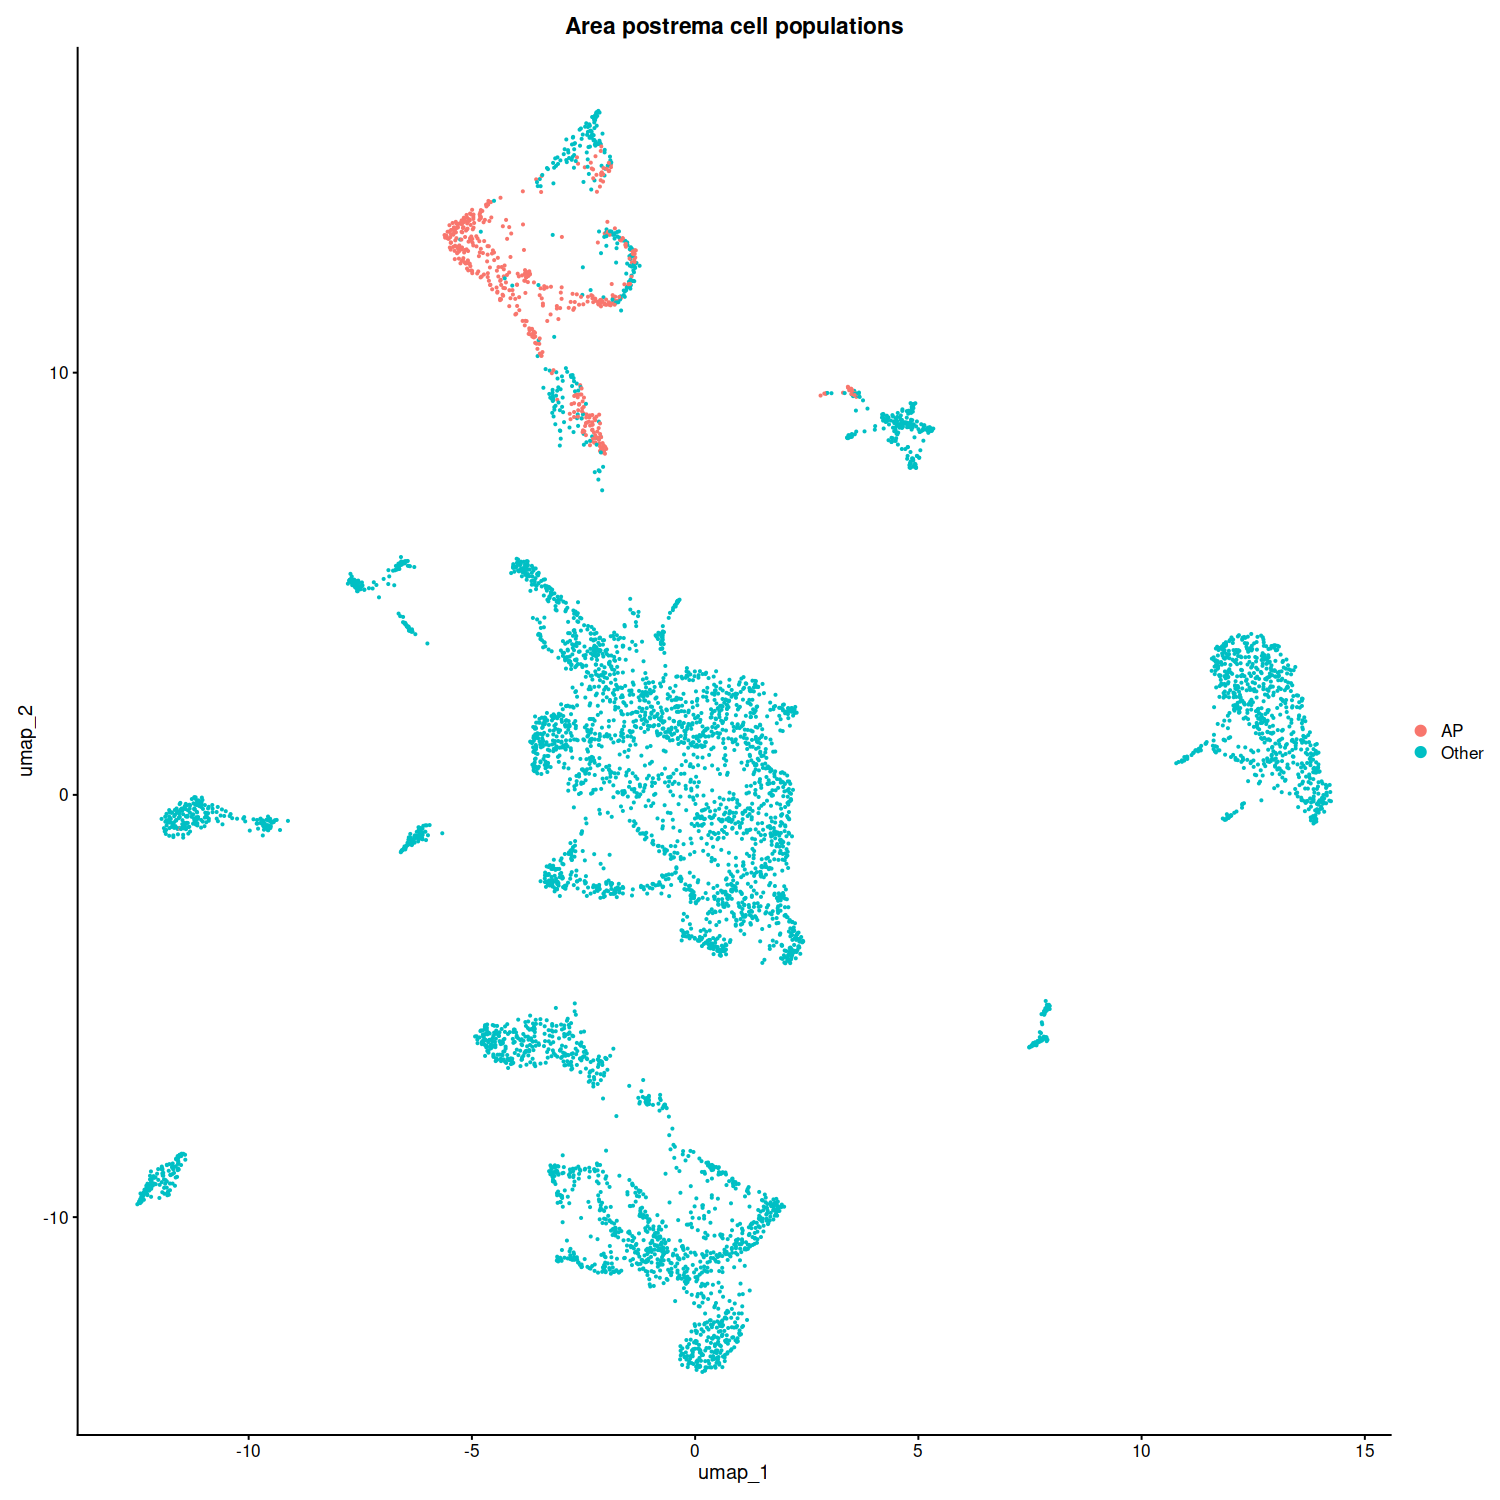

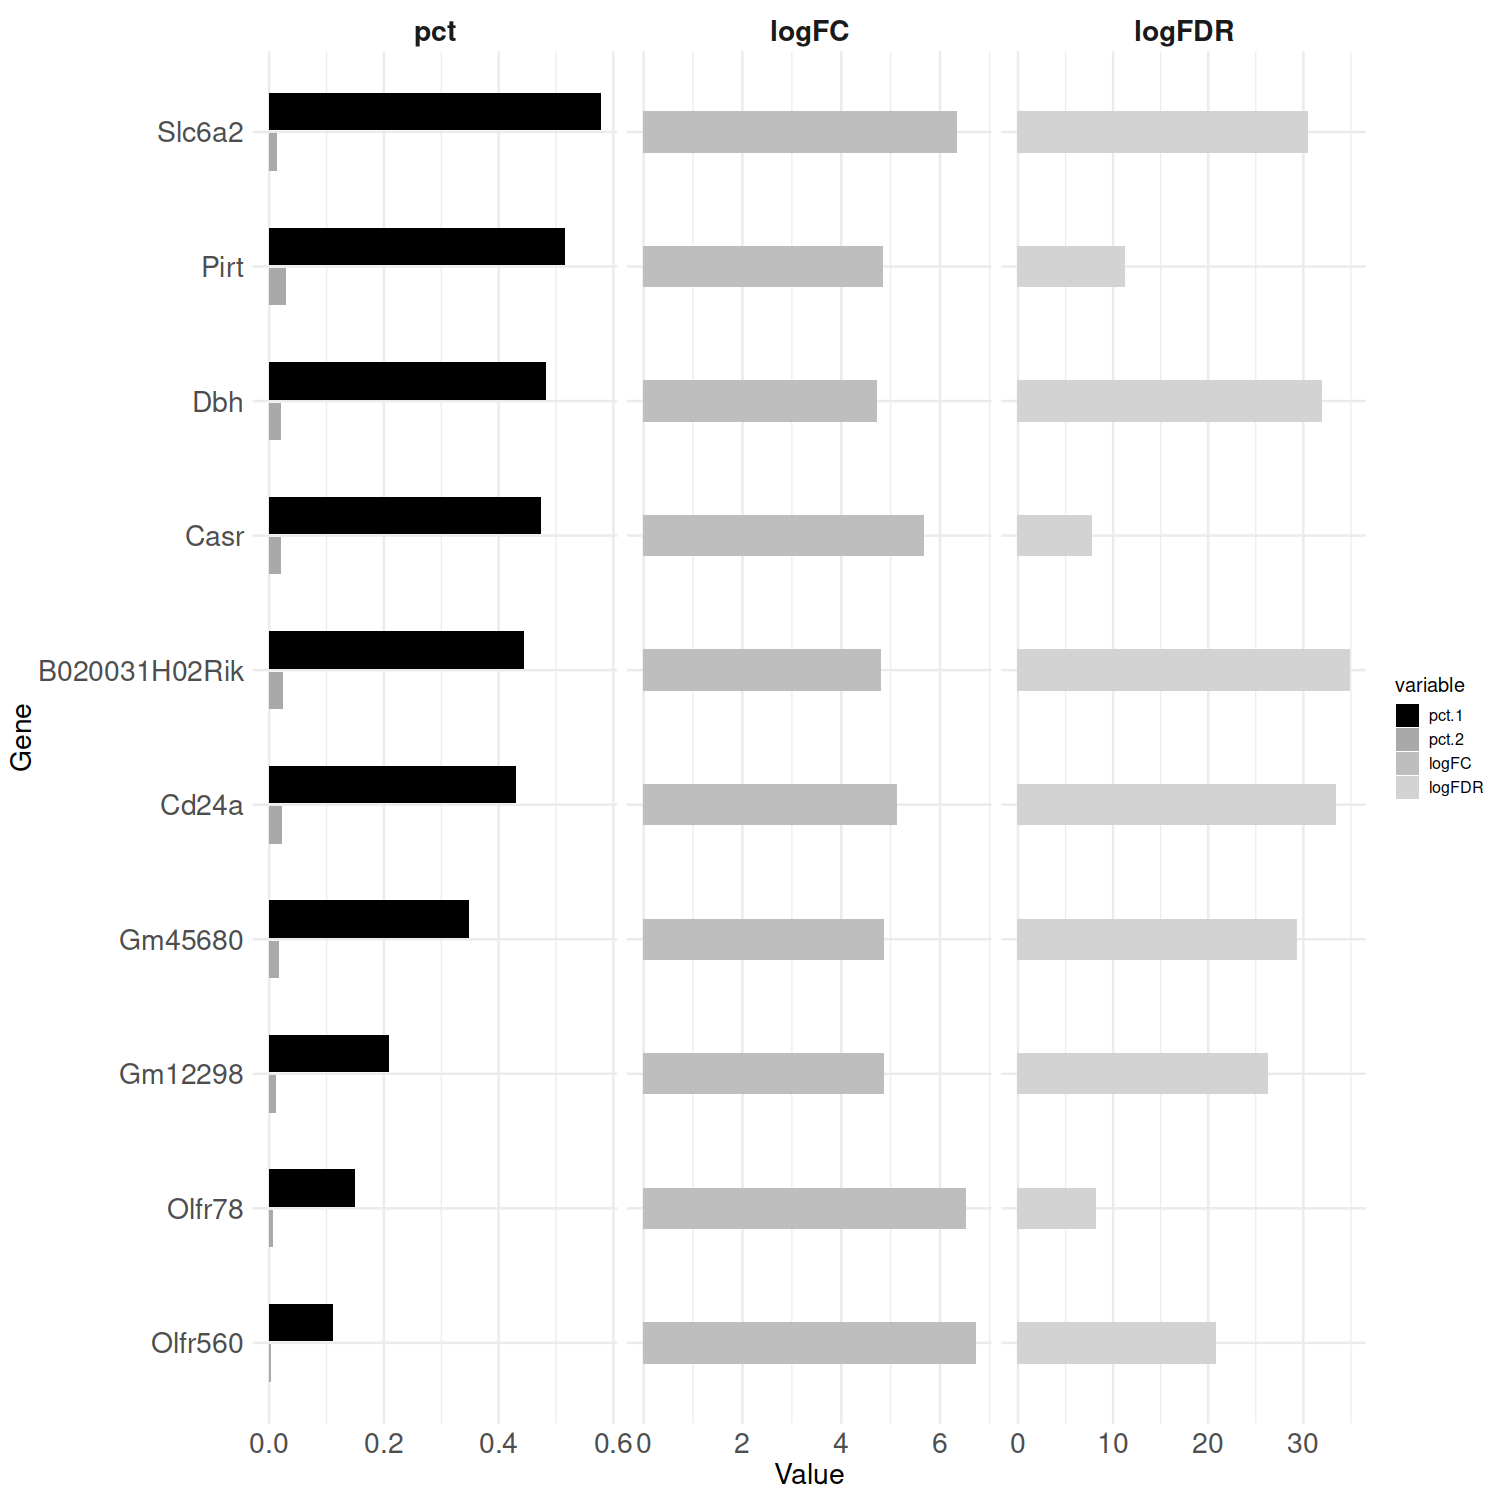

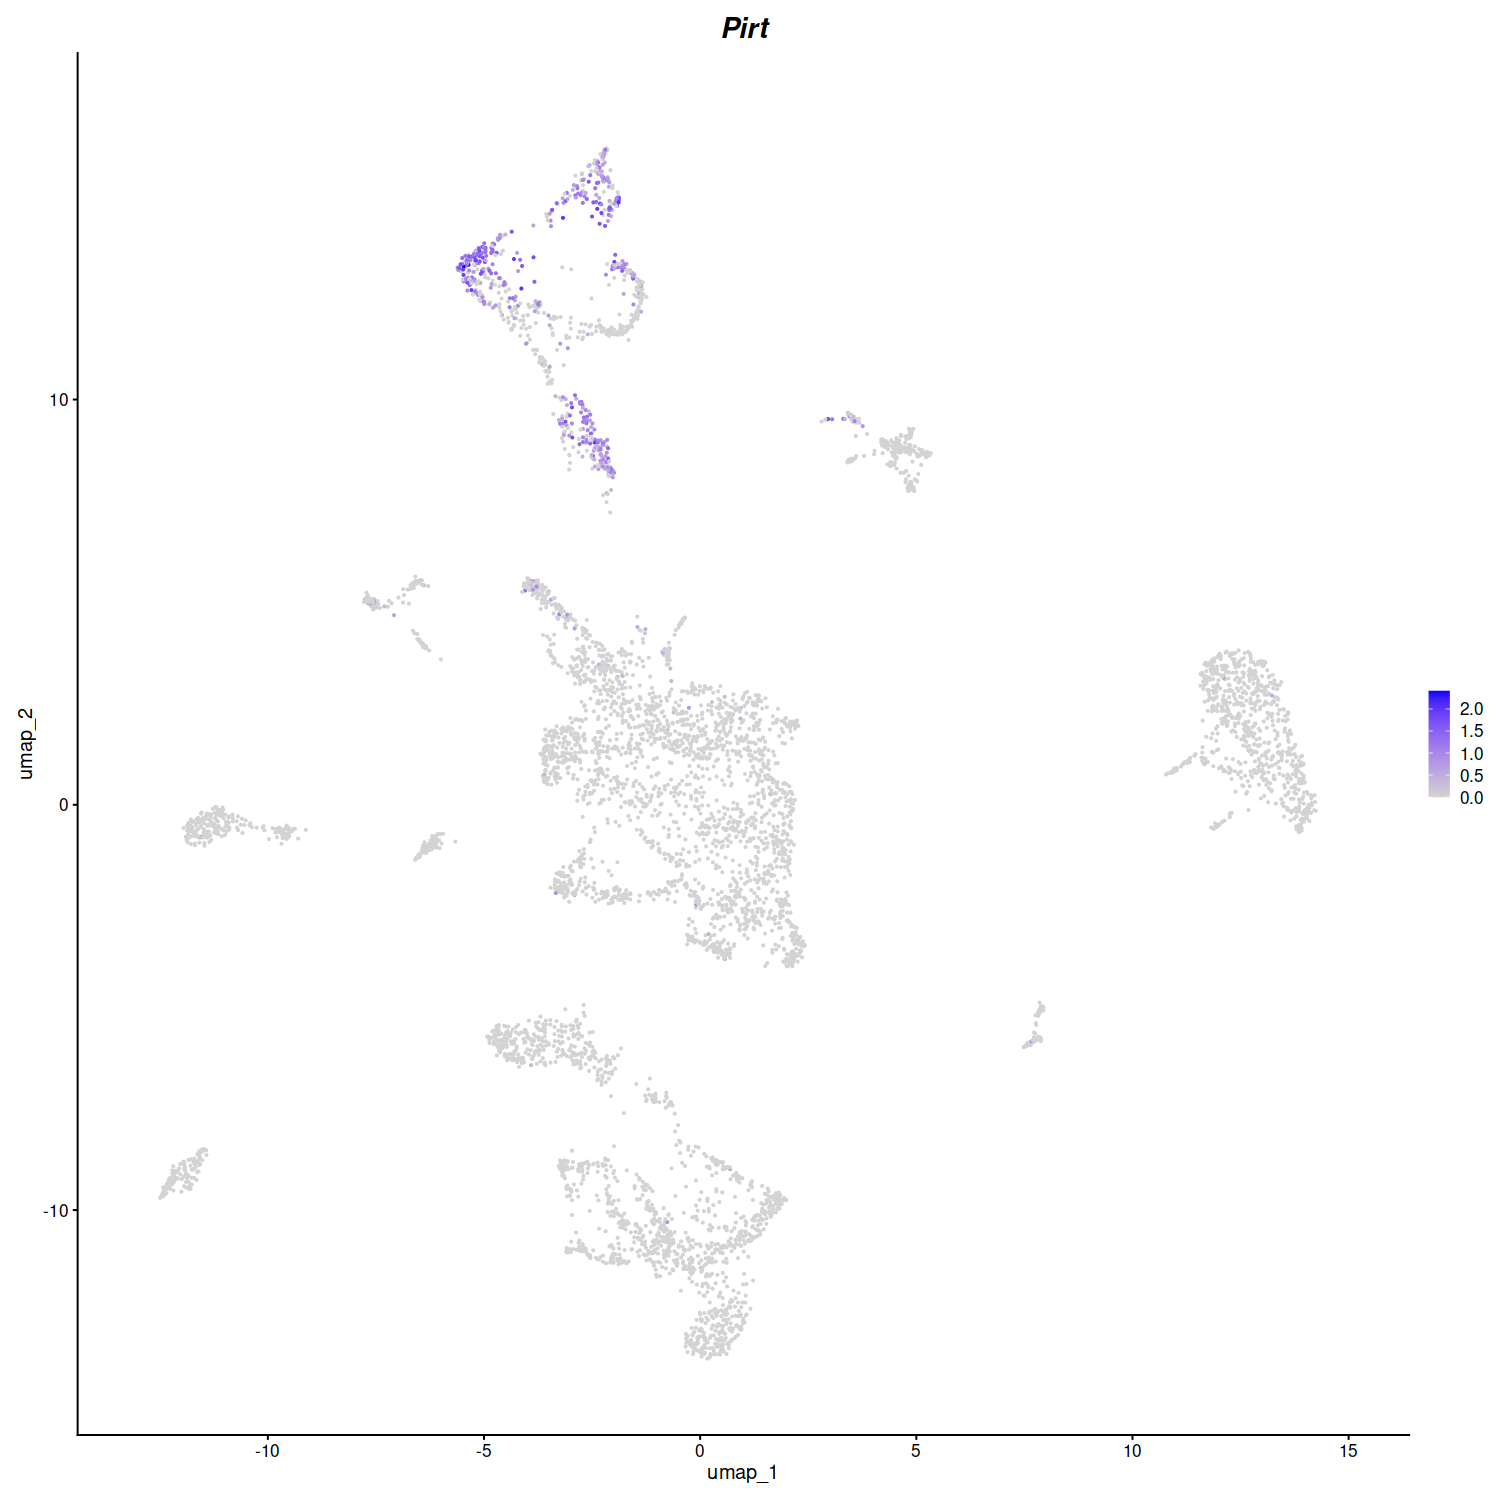

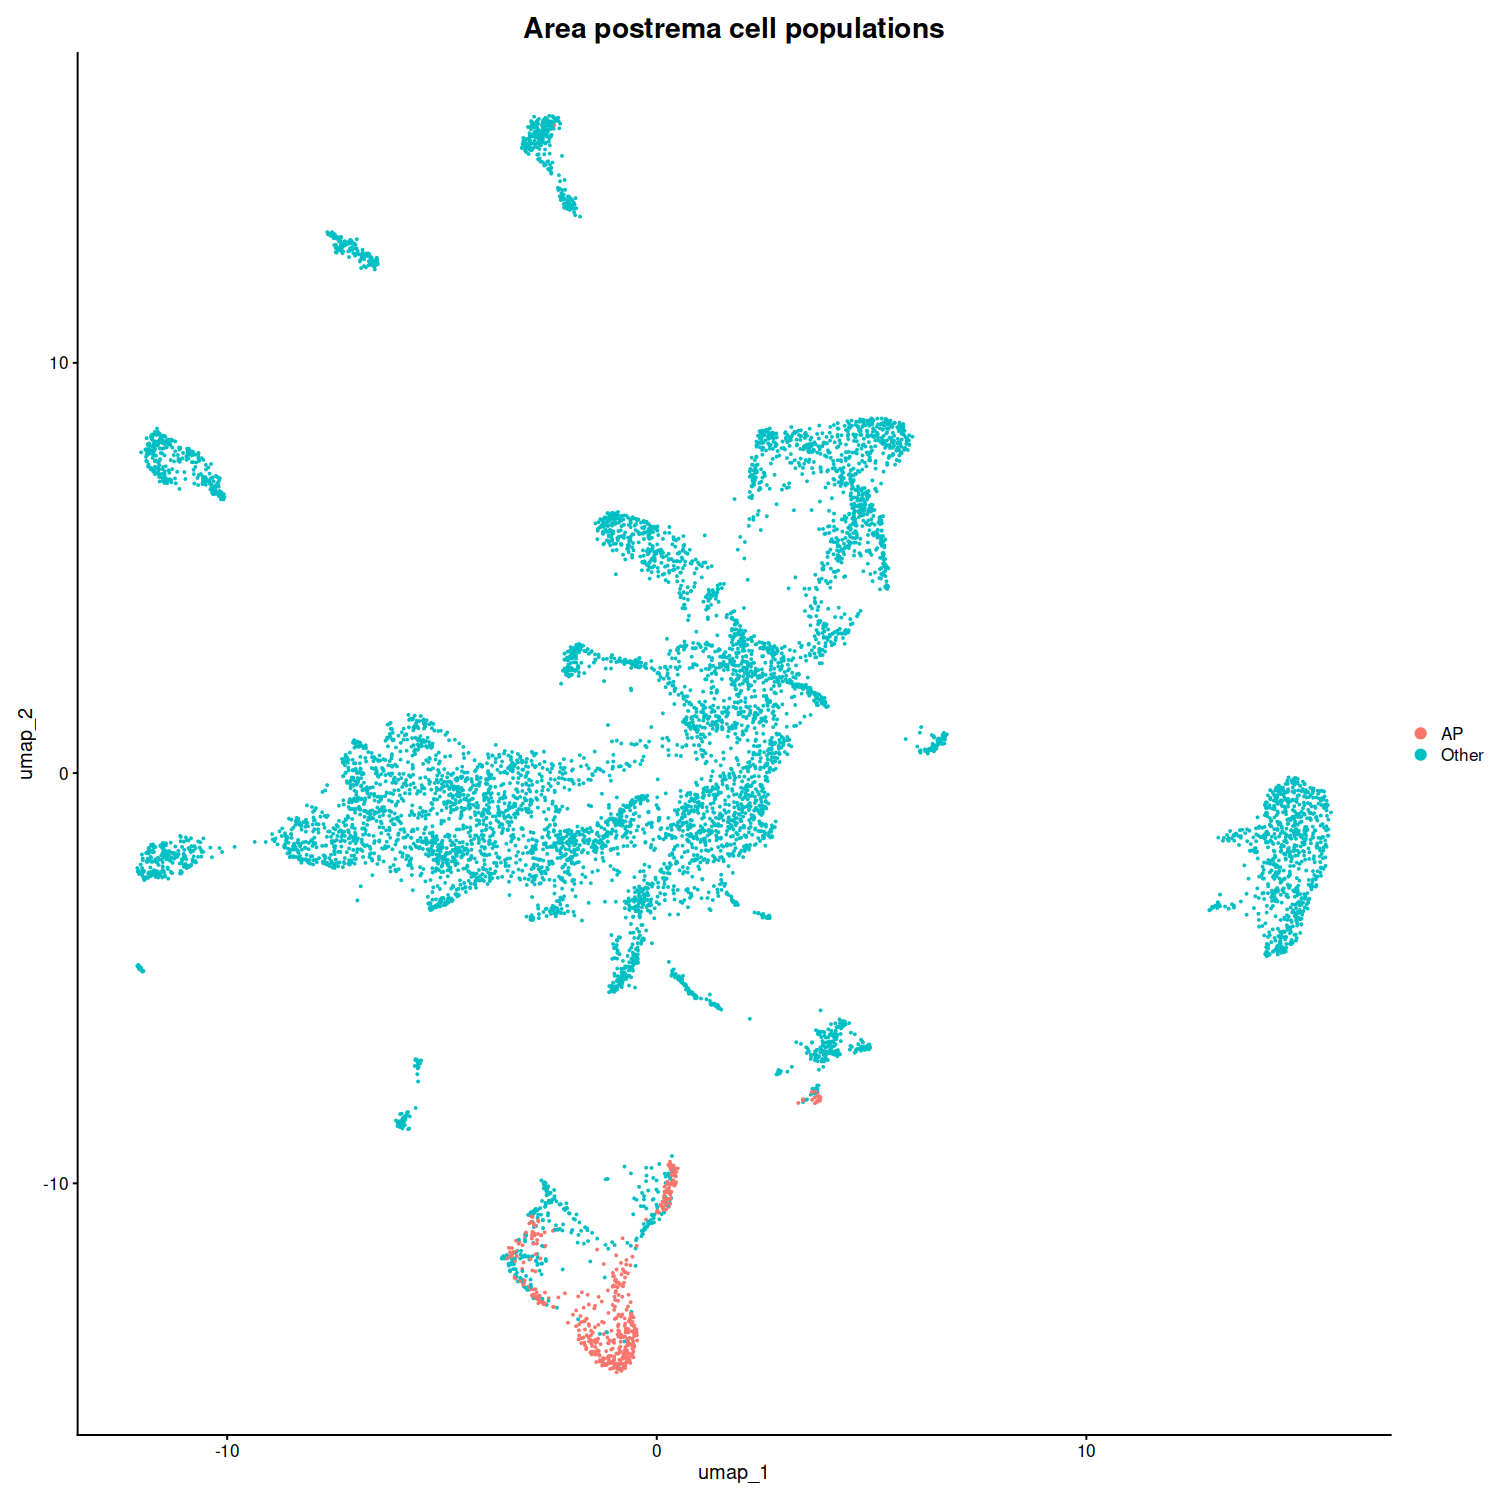

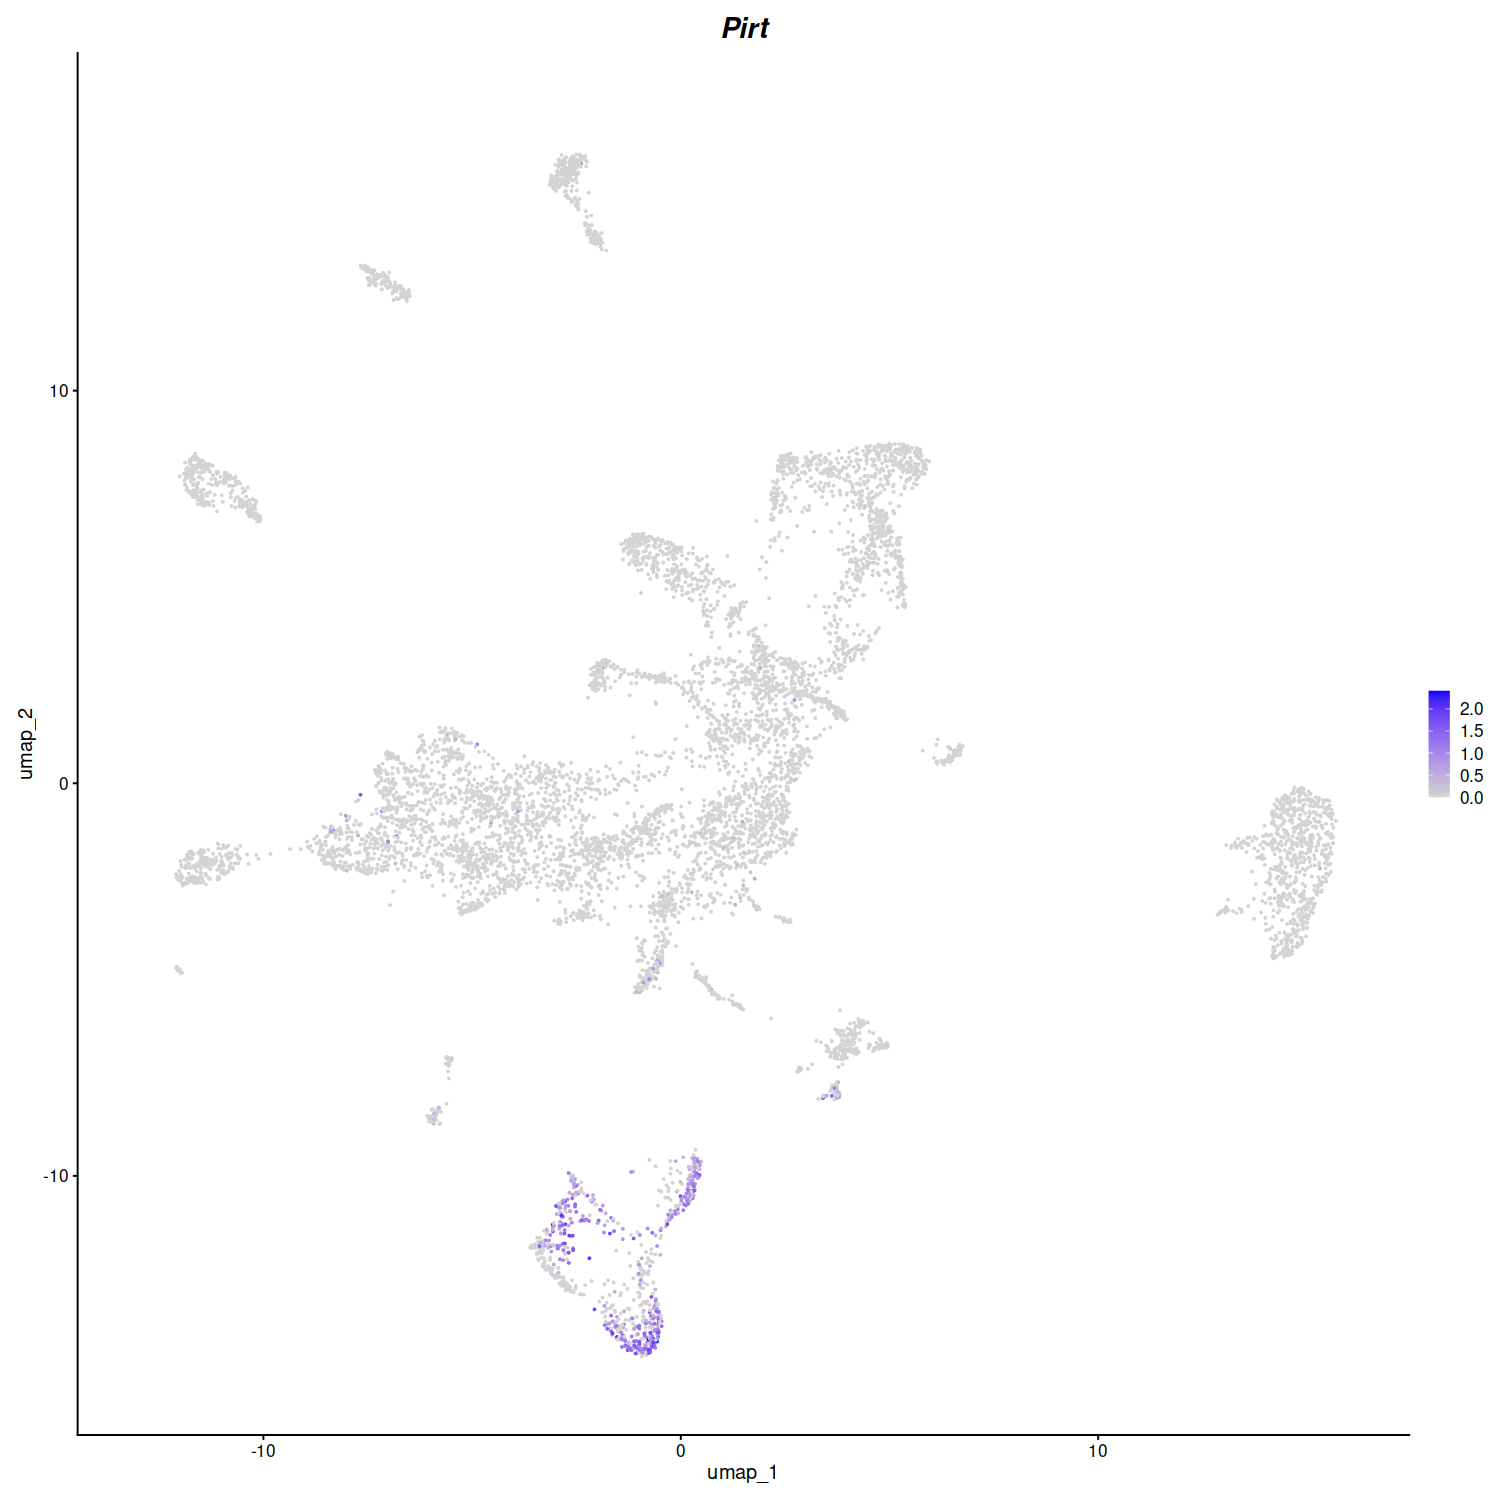

In [10]:
pdf("martin_glpr1-sun1_figures_glp1ronly.pdf", width = 15, height = 15, onefile = TRUE)  # `onefile = TRUE` ensures multiple pages

p1 <- DimPlot(sun1, group.by = "predicted.id.region")
print(p1)

p2 <- DimPlot(sun1_dvc, group.by = "predicted.id.dvc", label = TRUE) +
  guides(color = guide_legend(override.aes = list(size = 5), ncol = 2)) +
  ggtitle("DVC Labels from Ludwig, Coester, Gordian et. al 2025")
print(p2)

p3 <- DimPlot(sun1_dvc, group.by = "is_AP") +
  ggtitle("Area postrema cell populations")
print(p3)

p4 <- ggplot(plot_genes, aes(x = gene, y = value, fill = variable)) +
  geom_col(position = position_dodge2(preserve = "single"), width = 0.6) +
  coord_flip() +
  facet_wrap(~ facet_group, scales = "free_x", nrow = 1) +
  scale_fill_manual(values = c("black", "darkgray", "gray", "lightgray"),
                    breaks = c("pct.1", "pct.2", "logFC", "logFDR")) +
  labs(x = "Gene", y = "Value") +
  theme_minimal(base_size = 14) +
  theme(
    axis.text = element_text(size = 20),
    axis.title = element_text(size = 20),
    strip.text = element_text(size = 20, face = "bold"),
    plot.title = element_text(size = 20, face = "bold"))
print(p4)

p5 <- FeaturePlot(sun1_dvc, features = "Pirt") +
  theme(plot.title = element_text(face = "bold.italic", size = 20))
print(p5)

p6 <- DimPlot(sun1, group.by = "is_AP") +
  ggtitle("Area postrema cell populations") +
  theme(plot.title = element_text(size = 20))
print(p6)

p7 <- FeaturePlot(sun1, features = "Pirt") +
  theme(plot.title = element_text(face = "bold.italic", size = 20))
print(p7)

dev.off()

In [ ]:
pdf("martin_glpr1-sun1_figures.pdf", width = 15, height = 15)
DimPlot(sun1, group.by = "predicted.id.region")

DimPlot(sun1_dvc, group.by = "predicted.id.dvc", label = TRUE) +
  guides(color = guide_legend(override.aes = list(size = 5), ncol = 2)) +
  ggtitle("DVC Labels from Ludwig, Coester, Gordian et. al 2025")

DimPlot(sun1_dvc, group.by = "is_AP") +
  ggtitle("Area postrema cell populations")

ggplot(plot_genes, aes(x = gene, y = value, fill = variable)) +
  geom_col(position = position_dodge2(preserve = "single"), width = 0.6) +
  coord_flip() +
  facet_wrap(~ facet_group, scales = "free_x", nrow = 1) +
  scale_fill_manual(values = c("black", "darkgray", "gray", "lightgray"),
                    breaks = c("pct.1", "pct.2", "logFC", "logFDR")) +
  labs(x = "Gene", y = "Value") +
  theme_minimal(base_size = 14) +
  theme(
    axis.text = element_text(size = 20),
    axis.title = element_text(size = 20),
    strip.text = element_text(size = 20, face = "bold"),
    plot.title = element_text(size = 20, face = "bold"))

FeaturePlot(sun1_dvc, features = "Pirt") +
  theme(plot.title = element_text(face = "bold.italic", size = 20))

DimPlot(sun1, group.by = "is_AP") +
  ggtitle("Area postrema cell populations") +
  theme(plot.title = element_text(size = 20))

FeaturePlot(sun1, features = "Pirt") +
  theme(plot.title = element_text(face = "bold.italic", size = 20))
dev.off()

# Misc

In [ ]:
sun1_dvc$predicted.id.dvc <- gsub("_", ".", sun1_dvc$predicted.id.dvc)
numeric_mapping <- setNames(seq_along(mixedsort(unique(sun1_dvc$predicted.id.dvc))), mixedsort(unique(sun1_dvc$predicted.id.dvc)))
metadata_df <- data.frame(numeric_labels = numeric_mapping[sun1_dvc@meta.data$predicted.id.dvc],
                          row.names = rownames(sun1_dvc@meta.data))  # Ensure rownames match cell names
sun1_dvc <- AddMetaData(sun1_dvc, metadata = metadata_df)
sun1_dvc@meta.data$combined_labels <- NA  # Initialize with NA
valid_indices <- !is.na(sun1_dvc@meta.data$predicted.id.dvc)  # Identify valid rows
sun1_dvc@meta.data$combined_labels[valid_indices] <- 
  paste0(sun1_dvc@meta.data$numeric_labels[valid_indices], ". ", 
         sun1_dvc@meta.data$predicted.id.dvc[valid_indices])
sorted_levels <- mixedsort(unique(na.omit(sun1_dvc@meta.data$combined_labels)))  
sun1_dvc@meta.data$combined_labels <- factor(sun1_dvc@meta.data$combined_labels, levels = sorted_levels)


pdf("extra_umaps_glpr1-sun1_figures.pdf", width = 15, height = 15, onefile = TRUE)  # `onefile = TRUE` ensures multiple pages
p2 <- DimPlot(sun1_dvc, group.by = "numeric_labels", label = TRUE) +
  guides(color = guide_legend(override.aes = list(size = 5), ncol = 2)) +
  ggtitle("DVC Labels from Ludwig, Coester, Gordian et. al 2025")
print(p2)
p2 <- DimPlot(sun1_dvc, group.by = "combined_labels", label = TRUE) +
  guides(color = guide_legend(override.aes = list(size = 5), ncol = 2)) +
  ggtitle("DVC Labels from Ludwig, Coester, Gordian et. al 2025")
print(p2)
dev.off()

# pdf("extra_umaps_glpr1-sun1_figures.pdf", width = 15, height = 15, onefile = TRUE)
# p2 <- DimPlot(sun1_dvc, group.by = "numeric_labels", label = TRUE, raster = TRUE) +
#   guides(color = guide_legend(override.aes = list(size = 5), ncol = 2)) +
#   ggtitle("DVC Labels from Ludwig, Coester, Gordian et. al 2025")
# print(p2)
# p2 <- DimPlot(sun1_dvc, group.by = "combined_labels", label = TRUE, raster = TRUE) +
#   guides(color = guide_legend(override.aes = list(size = 5), ncol = 2)) +
#   ggtitle("DVC Labels from Ludwig, Coester, Gordian et. al 2025")
# print(p2)
# dev.off()

In [ ]:
# DEG
run_pseudobulk <- function(seurat_obj, sample_col, aggregate_by, 
                           lib_size = 5e4, 
                           min_gene_count = 5, 
                           min.total_gene_count = 20) {
    # 1. Create 'group' to aggregate by (here it's AP or Other)
    if (length(aggregate_by) > 1) {
        seurat_obj$group <- apply(
            seurat_obj@meta.data[, aggregate_by], 1, paste, collapse = "_"
        )
    } else if (length(aggregate_by) == 1) {
        seurat_obj$group <- seurat_obj@meta.data[, aggregate_by]
    }

    # 2. Convert single-cell to pseudobulk 
    DefaultAssay(seurat_obj) <- "RNA"
    pseudo <- Seurat2PB(seurat_obj, 
                        sample  = sample_col, 
                        cluster = "group")

    # 3. Filter pseudobulk matrix
    keep_samples <- pseudo$samples$lib.size > lib_size  
    keep_genes   <- filterByExpr(pseudo, 
                                 group           = pseudo$samples$cluster, 
                                 min.count       = min_gene_count, 
                                 min.total.count = min.total_gene_count)
    pseudo <- pseudo[keep_genes, keep_samples, keep=FALSE]

    # 4. Append additional metadata
    meta <- seurat_obj[[]] %>%
        distinct(!!sym(sample_col), .keep_all = TRUE) 
    meta <- meta[match(pseudo$samples$sample, meta[[sample_col]]), ]
    pseudo$samples <- bind_cols(meta, pseudo$samples)

    # 5. Normalize library sizes
    pseudo <- normLibSizes(pseudo)

    return(pseudo)
}

sun1_pseudo <- run_pseudobulk(
    seurat_obj = sun1, 
    sample_col = "hash.mcl.ID", 
    aggregate_by = "is_AP"
)

sun1_pseudo$samples$cluster <- factor(sun1_pseudo$samples$cluster)
sun1_pseudo$samples$cluster <- relevel(sun1_pseudo$samples$cluster, ref = "Other")
sun1_pseudo$samples$sample <- factor(sun1_pseudo$samples$sample)
design_matrix <- model.matrix(~ sample + cluster, data = sun1_pseudo$samples)

sun1_pseudo <- estimateDisp(sun1_pseudo, design_matrix, robust = TRUE)

fit <- glmQLFit(sun1_pseudo, design_matrix, robust = TRUE)
qlf <- glmQLFTest(fit, coef = "clusterAP")
top_table <- topTags(qlf, n = Inf)

top_genes <- top_table[top_table$table$FDR < 0.05,]%>%
    as.data.frame() %>% 
    arrange(desc(logFC))

pcts <- FindMarkers(sun1, ident.1 = "AP", ident.2 = "Other")[rownames(top_genes),]

top_genes <- top_genes %>% 
    select(c("logFC", "FDR")) %>%
    mutate(pct.1 = pcts$pct.1, pct.2 = pcts$pct.2) %>%
    mutate(logFDR = -log10(FDR)) %>%
    rownames_to_column(var = "Gene")


In [ ]:
top_genes <- top_table[top_table$table$FDR < 0.05,]%>%
    as.data.frame() %>% 
    arrange(desc(logFC))

top_genes <- top_genes %>% 
    select(c("logFC", "FDR")) %>%
    mutate(pct.1 = pcts$pct.1, pct.2 = pcts$pct.2) %>%
    mutate(logFDR = -log10(FDR)) %>%
    rownames_to_column(var = "Gene")

write.xlsx(top_genes, "pseudobulk_DEGs_summary.xlsx")